# Tiền xử lý dữ liệu (Lần đầu)
> Tập dữ liệu: NIH Chest X-Ray 14

## 1.  Thiết lập
### 1.1 Khai báo thư viện + Biến cố định

In [1]:
import sys
from pathlib import Path
if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

from utilities.tqdm import TqdmComma
from utilities.config import IMAGE_EXTENSION, ORIGINAL_DATASET_DIRECTORY, DATASET_DIRECTORY, TEST_DIRECTORY, DATASET_INFO_DIRECTORY, IMAGE_SIZE, TRAIN_FOLDS_DIRECTORY, NUMBER_OF_FOLDS, SEED, MIN_MESSAGE_WIDTH, MIN_NUMBER_WIDTH, CUDNN_DETERMINISTIC, CUDNN_BENCHMARK, DETERMINISTIC_ALGORITHMS
from utilities.notice import print_title, print_result, print_message, print_heading
from utilities.other import to_snake_case

from matplotlib.ticker import PercentFormatter
import json
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
import shutil

all_valid = True
RESIZED_DIRECTORY = DATASET_DIRECTORY / f"images"

### 1.2. Cài đặt chung

In [2]:
DATASET_NAME                = "NIH Chest X-Ray 14"

IMAGE_DIRECTORY             = (ORIGINAL_DATASET_DIRECTORY / "NIH_ChestXRay14" / "images").resolve()
DATA_ENTRY_CSV_DIRECTORY    = (ORIGINAL_DATASET_DIRECTORY / "NIH_ChestXRay14" / "Data_Entry_2017_v2020.csv").resolve()
TRAIN_SPLIT_DIRECTORY       = (ORIGINAL_DATASET_DIRECTORY / "NIH_ChestXRay14" / "train_val_list.txt").resolve()
TEST_SPLIT_DIRECTORY        = (ORIGINAL_DATASET_DIRECTORY / "NIH_ChestXRay14" / "test_list.txt").resolve()

RESIZE_IMAGES               = True

ID_COLUMN                   = "Image Index"
LABEL_COLUMN                = "Finding Labels"
PATIENT_ID_COLUMN           = "Patient ID"
NO_FINDING_LABEL            = "No Finding"
LABEL_SEPARATOR             = "|"    

### 1.3. Kiểm tra thông tin cài đặt

#### 1.3.1. Kiểm tra đường dẫn đầu vào 
> Input directory check

In [3]:
print_title("[1] KIỂM TRA ĐƯỜNG DẪN DỮ LIỆU ĐẦU VÀO")

paths_to_check = {
    "IMAGE_DIRECTORY"          : IMAGE_DIRECTORY,
    "DATA_ENTRY_CSV_DIRECTORY" : DATA_ENTRY_CSV_DIRECTORY,
    "TRAIN_SPLIT_DIRECTORY"    : TRAIN_SPLIT_DIRECTORY,
    "TEST_SPLIT_DIRECTORY"     : TEST_SPLIT_DIRECTORY,
}

for name, path in paths_to_check.items():
    exists = path.exists()

    if exists:
        print_result("[OK]"     , name, path)
                
    else:
        print_result("[MISSING]", name, path)
        all_valid = False

[1] KIỂM TRA ĐƯỜNG DẪN DỮ LIỆU ĐẦU VÀO
----------------------------------------------------------------------------------------------------
[OK]       IMAGE_DIRECTORY               : E:\New folder\chest_classification\train_models\original_dataset\NIH_ChestXRay14\images
[OK]       DATA_ENTRY_CSV_DIRECTORY      : E:\New folder\chest_classification\train_models\original_dataset\NIH_ChestXRay14\Data_Entry_2017_v2020.csv
[OK]       TRAIN_SPLIT_DIRECTORY         : E:\New folder\chest_classification\train_models\original_dataset\NIH_ChestXRay14\train_val_list.txt
[OK]       TEST_SPLIT_DIRECTORY          : E:\New folder\chest_classification\train_models\original_dataset\NIH_ChestXRay14\test_list.txt


#### 1.3.2. Kiểm tra cấu hình cột và nhãn

In [4]:
print_title("[2] KIỂM TRA CẤU HÌNH CỘT VÀ NHÃN")

# =========================
# Kiểm tra cấu hình cột dữ liệu
# =========================
column_configs = {
    "ID_COLUMN"         : ID_COLUMN,
    "LABEL_COLUMN"      : LABEL_COLUMN,
    "PATIENT_ID_COLUMN" : PATIENT_ID_COLUMN,
    "LABEL_SEPARATOR"   : LABEL_SEPARATOR,
    "NO_FINDING_LABEL"  : NO_FINDING_LABEL,
}

for name, value in column_configs.items():

    if isinstance(value, str) and value.strip():
        
        print_result("[OK]"     , name, value)

    else:

        print_result("[INVALID]" , name, "Phải là chuỗi không rỗng.")
        all_valid = False

# =========================
# Kiểm tra tên cột trùng nhau
# =========================
required_column_names = [ID_COLUMN, LABEL_COLUMN, PATIENT_ID_COLUMN]

if len(required_column_names) == len(set(required_column_names)):

    print_result("[OK]"     , "Kiểm tra cột trùng nhau", "Không trùng nhau")

else:

    print_result("[INVALID]", "Kiểm tra cột trùng nhau", "Có tên cột bị trùng")
    all_valid = False

[2] KIỂM TRA CẤU HÌNH CỘT VÀ NHÃN
----------------------------------------------------------------------------------------------------
[OK]       ID_COLUMN                     : Image Index
[OK]       LABEL_COLUMN                  : Finding Labels
[OK]       PATIENT_ID_COLUMN             : Patient ID
[OK]       LABEL_SEPARATOR               : |
[OK]       NO_FINDING_LABEL              : No Finding
[OK]       Kiểm tra cột trùng nhau       : Không trùng nhau


#### 1.3.3. Kiểm tra tệp CSV

In [5]:
print_title("[3] KIỂM TRA DỮ LIỆU TRONG TỆP TIN CSV")

dataset_df = pd.read_csv(DATA_ENTRY_CSV_DIRECTORY)

required_columns = {ID_COLUMN, LABEL_COLUMN, PATIENT_ID_COLUMN}
loaded_dataframes = {}

dataset_checks = {
    "IMAGE ID THIẾU"  : int(dataset_df[ID_COLUMN].isna().sum()),
    "IMAGE ID TRÙNG"  : int(dataset_df[ID_COLUMN].duplicated().sum()),
    "PATIENT ID THIẾU": int(dataset_df[PATIENT_ID_COLUMN].isna().sum()),
    "LABEL THIẾU"     : int(dataset_df[LABEL_COLUMN].isna().sum()),
    "LABEL RỖNG"      : int(dataset_df[LABEL_COLUMN].fillna("").astype(str).str.strip().eq("").sum()),
}

for check_name, count in dataset_checks.items():
    status = "[OK]" if count == 0 else "[INVALID]"
    print_result(status, check_name, f"{count:<{MIN_NUMBER_WIDTH},} dữ liệu")

    if count > 0:
        all_valid = False   

[3] KIỂM TRA DỮ LIỆU TRONG TỆP TIN CSV
----------------------------------------------------------------------------------------------------
[OK]       IMAGE ID THIẾU                : 0        dữ liệu
[OK]       IMAGE ID TRÙNG                : 0        dữ liệu
[OK]       PATIENT ID THIẾU              : 0        dữ liệu
[OK]       LABEL THIẾU                   : 0        dữ liệu
[OK]       LABEL RỖNG                    : 0        dữ liệu


#### 1.3.4. Kiểm tra No Finding

In [6]:
print_title("[4] KIỂM TRA NO FINDING")

labels_series = dataset_df[LABEL_COLUMN].fillna("").astype(str).str.strip()
invalid_no_finding = (
    labels_series
    .str.split(LABEL_SEPARATOR, regex=False)
    .apply(lambda labels: NO_FINDING_LABEL in labels and len(labels) > 1)
    .sum()
)

print_result("[INFO]", 'No Finding', f"{(labels_series == NO_FINDING_LABEL).sum():<{MIN_NUMBER_WIDTH},} dữ liệu")

status = "[OK]" if invalid_no_finding == 0 else "[INVALID]"
print_result(status, "No Finding + bệnh", f"{int(invalid_no_finding):<{MIN_NUMBER_WIDTH},} dữ liệu")

if invalid_no_finding > 0:
    all_valid = False

[4] KIỂM TRA NO FINDING
----------------------------------------------------------------------------------------------------
[INFO]     No Finding                    : 60,361   dữ liệu
[OK]       No Finding + bệnh             : 0        dữ liệu


#### 1.3.5. Kiểm tra tập dữ liệu huấn luyện và kiểm tra

In [7]:
print_title("[5] KIỂM TRA TẬP HUẤN LUYỆN VÀ TẬP KIỂM TRA")

with open(TRAIN_SPLIT_DIRECTORY, "r", encoding="utf-8") as file:
    train_val_images = [line.strip() for line in file if line.strip()]

with open(TEST_SPLIT_DIRECTORY, "r", encoding="utf-8") as file:
    test_images = [line.strip() for line in file if line.strip()]
    
dataset_images = set(dataset_df[ID_COLUMN].astype(str))
train_val_set = set(train_val_images)
test_set = set(test_images)

split_checks = {
    "Trùng dữ liệu tập huấn luyện ": len(train_val_images) - len(train_val_set),
    "Trùng dữ liệu tập kiểm tra"   : len(test_images) - len(test_set),
    
    "Thiếu dữ liệu tập huấn luyện": len(train_val_set - dataset_images),
    "Thiếu dữ liệu tập kiểm tra"  : len(test_set - dataset_images),
    
    "Trùng dữ liệu giữa hai tập"  : len(train_val_set & test_set),
}

for check_name, count in split_checks.items():
    status = "[OK]" if count == 0 else "[INVALID]"
    print_result(status, check_name, f"{count:<{MIN_NUMBER_WIDTH},} dữ liệu")

    if count > 0:
        all_valid = False

[5] KIỂM TRA TẬP HUẤN LUYỆN VÀ TẬP KIỂM TRA
----------------------------------------------------------------------------------------------------
[OK]       Trùng dữ liệu tập huấn luyện  : 0        dữ liệu
[OK]       Trùng dữ liệu tập kiểm tra    : 0        dữ liệu
[OK]       Thiếu dữ liệu tập huấn luyện  : 0        dữ liệu
[OK]       Thiếu dữ liệu tập kiểm tra    : 0        dữ liệu
[OK]       Trùng dữ liệu giữa hai tập    : 0        dữ liệu


#### 1.3.6. Kiểm tra các bệnh từ tập dữ liệu

In [8]:
print_title("[6] CÁC LỚP NHÃN BỆNH TRONG TẬP DỮ LIỆU")

CLASSES = sorted({
    label.strip()
    for value in labels_series
    for label in value.split(LABEL_SEPARATOR)
    if label.strip() and label.strip() != NO_FINDING_LABEL
})

print_result("[INFO]", "Số bệnh", f"{len(CLASSES):<{MIN_NUMBER_WIDTH},} nhãn bệnh")

print("\nCác loại nhãn bệnh trong tập dữ liệu:")
for index, label in enumerate(CLASSES, start=1):
    print(f"{index:>2}. {label}")
        

[6] CÁC LỚP NHÃN BỆNH TRONG TẬP DỮ LIỆU
----------------------------------------------------------------------------------------------------
[INFO]     Số bệnh                       : 14       nhãn bệnh

Các loại nhãn bệnh trong tập dữ liệu:
 1. Atelectasis
 2. Cardiomegaly
 3. Consolidation
 4. Edema
 5. Effusion
 6. Emphysema
 7. Fibrosis
 8. Hernia
 9. Infiltration
10. Mass
11. Nodule
12. Pleural_Thickening
13. Pneumonia
14. Pneumothorax


#### 1.3.7. Kiểm tra ảnh trong tập dữ liệu

In [9]:
print_title("[7] KIỂM TRA ẢNH TRONG TẬP DỮ LIỆU")

image_files = [
    path for path in IMAGE_DIRECTORY.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSION
]

image_map = {path.name: path.resolve() for path in image_files}
required_split_images = train_val_set | test_set
missing_physical_images = required_split_images - set(image_map)

print_result("[INFO]", "Ảnh tìm thấy", f"{len(image_map):<{MIN_NUMBER_WIDTH},} ảnh")
print_result("[INFO]", "Ảnh khớp trong tập dữ liệu", f"{len(required_split_images):<{MIN_NUMBER_WIDTH},} ảnh")

if missing_physical_images:
    print_result("[INVALID]", "Ảnh bị thiếu", f"{len(missing_physical_images):<{MIN_NUMBER_WIDTH},} ảnh")
    print("Ví dụ:", sorted(missing_physical_images)[:10])
    all_valid = False
    
else:
    
    print_result("[OK]", "Ảnh bị thiếu", f"{len(missing_physical_images):<{MIN_NUMBER_WIDTH},} ảnh")

[7] KIỂM TRA ẢNH TRONG TẬP DỮ LIỆU
----------------------------------------------------------------------------------------------------
[INFO]     Ảnh tìm thấy                  : 112,120  ảnh
[INFO]     Ảnh khớp trong tập dữ liệu    : 112,120  ảnh
[OK]       Ảnh bị thiếu                  : 0        ảnh


#### 1.3.8. Kiểm tra thư mục đầu ra

In [10]:
print_title("[8] KIỂM TRA ẢNH TRONG TẬP DỮ LIỆU")

if not DATASET_DIRECTORY.exists():
    DATASET_DIRECTORY.mkdir(parents=True, exist_ok=True)
    
    print_result("[CREATED]", "DATASET_DIRECTORY", DATASET_DIRECTORY)
    
else:
    print_result("[OK]", "DATASET_DIRECTORY", DATASET_DIRECTORY)

[8] KIỂM TRA ẢNH TRONG TẬP DỮ LIỆU
----------------------------------------------------------------------------------------------------
[CREATED]  DATASET_DIRECTORY             : E:\New folder\chest_classification\train_models\dataset


#### 1.3.9. Những thiết lập khác

In [11]:
print_title("[9] KIỂM TRA CẤU HÌNH KHÁC")

# NUMBER_OF_FOLDS
if isinstance(NUMBER_OF_FOLDS, int) and NUMBER_OF_FOLDS >= 2:
    print_result("[OK]", "NUMBER_OF_FOLDS", f"{NUMBER_OF_FOLDS:<{MIN_NUMBER_WIDTH},} lần")

else:
    print_result("[INVALID]", "NUMBER_OF_FOLDS", "Giá trị phải lớn hơn 1")
    all_valid = False

# SEED
if isinstance(SEED, int):
    print_result("[OK]", "SEED", f"{NUMBER_OF_FOLDS:<{MIN_NUMBER_WIDTH},}")

else:
    
    print_result("[INVALID]", "SEED", "phải là số")
    all_valid = False

# RESIZE_IMAGES
if isinstance(RESIZE_IMAGES, bool):
    
    print_result("[OK]", "RESIZE_IMAGES", RESIZE_IMAGES)
    
else:
    
    print_result("[INVALID]", "RESIZE_IMAGES", f"RESIZE_IMAGES phải là bool (True/False), nhưng nhận được: {RESIZE_IMAGES}")
    all_valid = False

# IMAGE_SIZE
if isinstance(IMAGE_SIZE, int) and not isinstance(IMAGE_SIZE, bool):

    if IMAGE_SIZE > 0:
        
        print_result("[OK]", "IMAGE_SIZE", f"{IMAGE_SIZE} x {IMAGE_SIZE}")
        
    else:
        
        print_result("[INVALID]", "IMAGE_SIZE", f"IMAGE_SIZE phải lớn hơn 0, nhưng nhận được: {IMAGE_SIZE}")
        all_valid = False

else:
    
    print_result("[INVALID]", "IMAGE_SIZE", f"IMAGE_SIZE phải là số nguyên, nhưng nhận được: {IMAGE_SIZE}")
    all_valid = False

# Hiển thị cấu hình resize thực tế
if (
    isinstance(RESIZE_IMAGES, bool)
    and RESIZE_IMAGES
    and isinstance(IMAGE_SIZE, int)
    and not isinstance(IMAGE_SIZE, bool)
    and IMAGE_SIZE > 0
):
    if not RESIZED_DIRECTORY.exists():
        RESIZED_DIRECTORY.mkdir(parents=True, exist_ok=True)
        
        print_result("[CREATED]", "RESIZED_DIRECTORY", RESIZED_DIRECTORY)
        
    else:
        
        print_result("[OK]", "RESIZED_DIRECTORY", RESIZED_DIRECTORY)

elif isinstance(RESIZE_IMAGES, bool) and not RESIZE_IMAGES:
    
    print_result("[INFO]", "RESIZED_DIRECTORY", "Resize ảnh đang tắt. Ảnh sẽ giữ kích thước gốc.")

[9] KIỂM TRA CẤU HÌNH KHÁC
----------------------------------------------------------------------------------------------------
[OK]       NUMBER_OF_FOLDS               : 5        lần
[OK]       SEED                          : 5       
[OK]       RESIZE_IMAGES                 : True
[OK]       IMAGE_SIZE                    : 224 x 224
[CREATED]  RESIZED_DIRECTORY             : E:\New folder\chest_classification\train_models\dataset\images


#### 1.3.10. Tổng kết

In [12]:
print("=" * 100)

if all_valid:
    
    print("TẤT CẢ DỮ LIỆU VÀ CẤU HÌNH ĐỀU HỢP LỆ.")
    print("=" * 100)

else:
    
    print("PHÁT HIỆN DỮ LIỆU HOẶC CẤU HÌNH KHÔNG HỢP LỆ.")
    print("KIỂM TRA CÁC MỤC [MISSING] / [INVALID] Ở TRÊN.")
    print("=" * 100)

    assert all_valid, "Thiết lập không hợp lệ."

TẤT CẢ DỮ LIỆU VÀ CẤU HÌNH ĐỀU HỢP LỆ.


## 2. Tạo DataFrame

In [13]:
train_df = dataset_df[dataset_df[ID_COLUMN].isin(train_val_set)].copy()
test_df = dataset_df[dataset_df[ID_COLUMN].isin(test_set)].copy()

# Sắp xếp theo danh sách
train_order = {name: index for index, name in enumerate(train_val_images)}
test_order = {name: index for index, name in enumerate(test_images)}

train_df["__order"] = train_df[ID_COLUMN].map(train_order)
test_df["__order"] = test_df[ID_COLUMN].map(test_order)

train_df = train_df.sort_values("__order").drop(columns="__order").reset_index(drop=True)
test_df = test_df.sort_values("__order").drop(columns="__order").reset_index(drop=True)

# Thống kê
total_images = len(train_df) + len(test_df)
total_patients = pd.concat([train_df[PATIENT_ID_COLUMN],test_df[PATIENT_ID_COLUMN]]).nunique()

print_message("Tập dữ liệu huấn luyện", f"{len(train_df)   :<{MIN_NUMBER_WIDTH},} ảnh | {train_df[PATIENT_ID_COLUMN].nunique()  :<{MIN_NUMBER_WIDTH},} bệnh nhân")
print_message("Tập dữ liệu kiểm tra"  , f"{len(test_df)    :<{MIN_NUMBER_WIDTH},} ảnh | {test_df[PATIENT_ID_COLUMN].nunique()   :<{MIN_NUMBER_WIDTH},} bệnh nhân")
print_message("Tổng cộng"             , f"{total_images    :<{MIN_NUMBER_WIDTH},} ảnh | {total_images                           :<{MIN_NUMBER_WIDTH},} bệnh nhân")

Tập dữ liệu huấn luyện        : 86,524   ảnh | 28,008   bệnh nhân
Tập dữ liệu kiểm tra          : 25,596   ảnh | 2,797    bệnh nhân
Tổng cộng                     : 112,120  ảnh | 112,120  bệnh nhân


## 3. Mã hóa nhãn dữ liệu
> Bằng phương pháp One-hot encoding

> No Finding được đánh dấu bằng cách toàn bộ giá trị trong vector về 0

In [14]:
def encode_labels(df, classes):
    df = df.copy()
    parsed_labels = df[LABEL_COLUMN].astype(str).str.split(LABEL_SEPARATOR)

    for label in classes:
        df[label] = parsed_labels.apply(lambda labels: int(label in labels)).astype(np.uint8)

    df["num_positive_labels"] = df[classes].sum(axis=1).astype(np.uint8)
    df["is_no_finding"] = df[LABEL_COLUMN].eq(NO_FINDING_LABEL).astype(np.uint8)

    # Kiểm tra No Finding phải có vector toàn 0
    invalid_no_finding_vector = ((df["is_no_finding"] == 1) & (df["num_positive_labels"] != 0)).sum()
    assert invalid_no_finding_vector == 0, "No Finding đang có nhãn bệnh dương tính."

    return df

train_df = encode_labels(train_df, CLASSES)
test_df = encode_labels(test_df, CLASSES)

print(train_df[[ID_COLUMN, PATIENT_ID_COLUMN, LABEL_COLUMN] + CLASSES].head())

        Image Index  Patient ID          Finding Labels  Atelectasis  \
0  00000001_000.png           1            Cardiomegaly            0   
1  00000001_001.png           1  Cardiomegaly|Emphysema            0   
2  00000001_002.png           1   Cardiomegaly|Effusion            0   
3  00000002_000.png           2              No Finding            0   
4  00000004_000.png           4             Mass|Nodule            0   

   Cardiomegaly  Consolidation  Edema  Effusion  Emphysema  Fibrosis  Hernia  \
0             1              0      0         0          0         0       0   
1             1              0      0         0          1         0       0   
2             1              0      0         1          0         0       0   
3             0              0      0         0          0         0       0   
4             0              0      0         0          0         0       0   

   Infiltration  Mass  Nodule  Pleural_Thickening  Pneumonia  Pneumothorax  
0        

## 4. Chia K-Fold
> Chia theo bệnh nhân theo Multi-label Stratified 

> Chỉ thực hiện trên tập huấn luyện, không thực hiện trên tập kiểm tra

### 4.1. Chia K-Fold

In [15]:
# Tạo ma trận nhãn ở mức patient
patient_labels_df = (train_df.groupby(PATIENT_ID_COLUMN, as_index=False)[CLASSES].max())

patient_ids = patient_labels_df[PATIENT_ID_COLUMN].to_numpy()
patient_y = patient_labels_df[CLASSES].to_numpy(dtype=np.uint8)
patient_x = np.arange(len(patient_labels_df)).reshape(-1, 1)

print_message("Số patient dùng cho K-Fold", f"{len(patient_labels_df):<{MIN_NUMBER_WIDTH},} bệnh nhân")
print_message("Số lớp"                    , f"{patient_y.shape[1]    :<{MIN_NUMBER_WIDTH},} nhãn bệnh\n")

# Chia K-Folds theo bệnh nhân
mskf = MultilabelStratifiedKFold(
    n_splits=NUMBER_OF_FOLDS,
    shuffle=True,
    random_state=SEED,
)

patient_to_fold = {}

for fold_index, (_, val_patient_idx) in enumerate(
    mskf.split(patient_x, patient_y)
):
    fold_number = fold_index + 1

    for patient_id in patient_ids[val_patient_idx]:
        patient_to_fold[patient_id] = fold_number

assert len(patient_to_fold) == len(patient_labels_df), "Có patient chưa được gán fold."


# Gán fold trở lại từng ảnh
train_df["Fold"] = (train_df[PATIENT_ID_COLUMN].map(patient_to_fold).astype(np.uint8))


# Kiểm tra
fold_counts = train_df["Fold"].value_counts().sort_index()

for fold, count in fold_counts.items():
    print(f"Fold {fold}: {count:<{MIN_NUMBER_WIDTH},} ảnh")

Số patient dùng cho K-Fold    : 28,008   bệnh nhân
Số lớp                        : 14       nhãn bệnh

Fold 1: 17,289   ảnh
Fold 2: 17,262   ảnh
Fold 3: 16,725   ảnh
Fold 4: 17,554   ảnh
Fold 5: 17,694   ảnh


### 4.2. Kiểm tra chia K-Fold

#### 4.2.1. Kiểm tra giá trị Fold

In [16]:
expected_folds = set(range(1, NUMBER_OF_FOLDS + 1))
actual_folds = set(train_df["Fold"].dropna().astype(int).unique())

assert actual_folds == expected_folds, f"Fold thực tế {actual_folds} khác {expected_folds}."
assert train_df["Fold"].isna().sum() == 0, "Có ảnh chưa được gán fold."

#### 4.2.2. Kiểm tra dữ liệu rò rỉ

In [17]:
fold_summary = []

for fold in range(1, NUMBER_OF_FOLDS + 1):

    fold_train = train_df[train_df["Fold"] != fold]
    fold_val   = train_df[train_df["Fold"] == fold]

    train_patients = set(fold_train[PATIENT_ID_COLUMN])
    val_patients   = set(fold_val[PATIENT_ID_COLUMN])

    patient_overlap = train_patients & val_patients

    assert len(patient_overlap) == 0, \
        f"Fold {fold} bị patient leakage."

    fold_summary.append({
        ("", "Fold"): fold,
        ("Số ảnh", "Huấn luyện"): len(fold_train),
        ("Số ảnh", "Kiểm thử"): len(fold_val),
        ("Số bệnh nhân", "Huấn luyện"): len(train_patients),
        ("Số bệnh nhân", "Kiểm thử"): len(val_patients),
    })

# Tạo DataFrame
fold_summary_df = pd.DataFrame(fold_summary)

# Chuyển tên cột thành MultiIndex để nhóm cột
fold_summary_df.columns = pd.MultiIndex.from_tuples(
    fold_summary_df.columns
)

# Định dạng bảng
styled_fold_summary = (
    fold_summary_df
    .style
    .hide(axis="index")
    .format({
        ("", "Fold"): "{:.0f}",
        ("Số ảnh", "Huấn luyện"): "{:,}",
        ("Số ảnh", "Kiểm thử"): "{:,}",
        ("Số bệnh nhân", "Huấn luyện"): "{:,}",
        ("Số bệnh nhân", "Kiểm thử"): "{:,}",
    })
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 15px",
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
                ("padding", "8px 15px"),
                ("border", "1px solid #cccccc"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid #dddddd"),
            ],
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "auto"),
            ],
        },
    ])
)

display(styled_fold_summary)

### 4.2.4. Tính Pos_weight

In [18]:
def calculate_class_statistics(df, classes):
    rows = []

    for label in classes:
        positive = int(df[label].sum())
        negative = int(len(df) - positive)
        positive_rate = positive / len(df) if len(df) else 0.0
        pos_weight = negative / positive if positive > 0 else 1.0

        rows.append({
            "class": label,
            "positive": positive,
            "negative": negative,
            "positive_rate": positive_rate,
            "pos_weight": pos_weight,
        })

    return pd.DataFrame(rows)

fold_outputs = {}

for fold in range(1, NUMBER_OF_FOLDS + 1):
    fold_directory = DATASET_DIRECTORY / "folds" / f"fold_{fold}"
    fold_directory.mkdir(parents=True, exist_ok=True)

    fold_train_df = train_df[train_df["Fold"] != fold].copy().reset_index(drop=True)
    fold_validation_df = train_df[train_df["Fold"] == fold].copy().reset_index(drop=True)

    # Safety check
    overlap = (
        set(fold_train_df[PATIENT_ID_COLUMN])
        & set(fold_validation_df[PATIENT_ID_COLUMN])
    )
    assert len(overlap) == 0, f"Fold {fold}: patient leakage."

    class_statistics_df = calculate_class_statistics(fold_train_df, CLASSES)
    pos_weight = class_statistics_df["pos_weight"].to_numpy(dtype=np.float32)

    fold_train_df.to_csv(fold_directory / "train.csv", index=False)
    fold_validation_df.to_csv(fold_directory / "validation.csv", index=False)
    class_statistics_df.to_csv(fold_directory / "class_statistics.csv", index=False)
    np.save(fold_directory / "pos_weight.npy", pos_weight)
    
    
# ============================================================
# Calculate Pos Weight for Full Training Dataset
# ============================================================


DATASET_DIRECTORY.mkdir(parents=True, exist_ok=True)

# Calculate class statistics
full_class_statistics_df = calculate_class_statistics(train_df, CLASSES)

# Calculate Pos Weight
full_pos_weight = full_class_statistics_df["pos_weight"].to_numpy(dtype=np.float32)

# Save results
full_class_statistics_df.to_csv(DATASET_DIRECTORY / "class_statistics.csv", index=False)

np.save(DATASET_DIRECTORY / "pos_weight.npy", full_pos_weight)

print("Đã lưu thành công")

Đã lưu thành công


#### 4.2.3. Thống kê phân bổ nhãn tập dữ liệu huấn luyện

Lớp,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
Không bệnh,58.15%,58.55%,58.46%,58.40%,58.26%
Atelectasis,9.64%,9.54%,9.56%,9.56%,9.54%
Cardiomegaly,1.99%,1.98%,1.96%,1.95%,1.98%
Consolidation,3.32%,3.24%,3.28%,3.32%,3.31%
Edema,1.61%,1.57%,1.60%,1.57%,1.61%
Effusion,10.13%,9.84%,10.03%,10.02%,10.01%
Emphysema,1.62%,1.65%,1.65%,1.65%,1.66%
Fibrosis,1.45%,1.44%,1.45%,1.43%,1.46%
Hernia,0.16%,0.17%,0.16%,0.17%,0.15%
Infiltration,16.01%,15.88%,15.99%,15.88%,15.88%


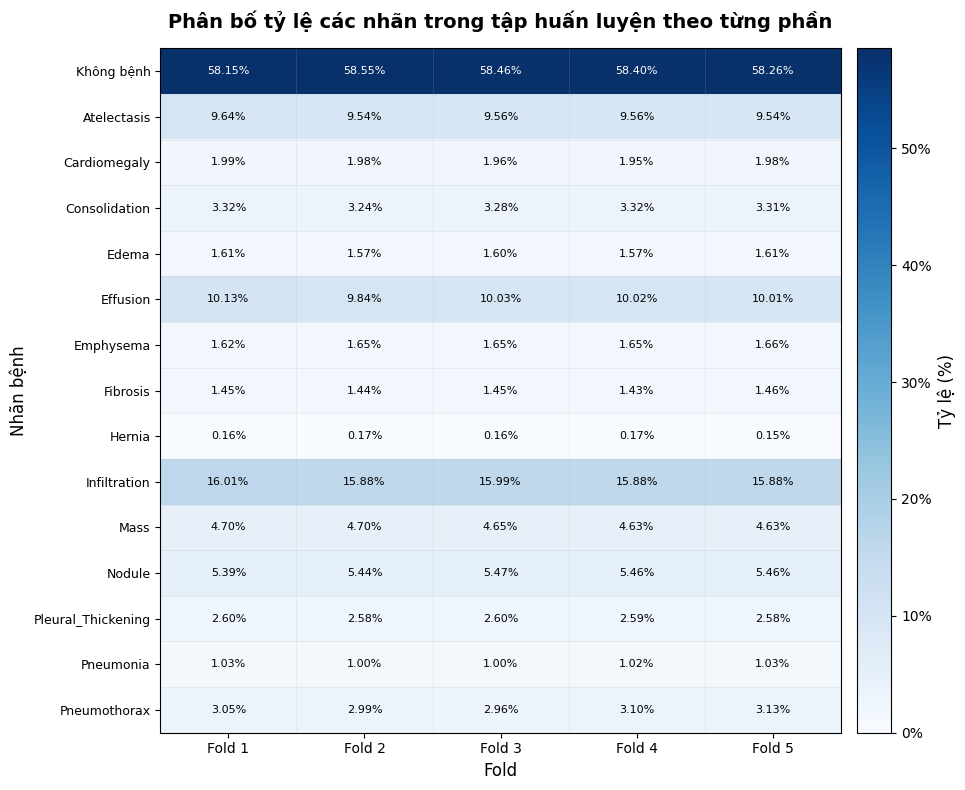

In [19]:
# Thống kê số liệu
train_distribution_rows = []

for fold in range(1, NUMBER_OF_FOLDS + 1):

    fold_train = train_df[train_df["Fold"] != fold]
    train_total = len(fold_train)

    # 14 nhãn bệnh
    for label in CLASSES:

        train_positive = int(fold_train[label].sum())
        train_distribution_rows.append({
            "Lớp": label,
            "Fold": fold,
            "Số ảnh dương tính": train_positive,
            "Tổng số ảnh": train_total,
            "Tỷ lệ": (train_positive / train_total if train_total > 0 else 0.0),
        })

    # No Finding
    train_no_finding = int((fold_train[CLASSES].sum(axis=1) == 0).sum())
    train_distribution_rows.append({
        "Lớp": NO_FINDING_LABEL,
        "Fold": fold,
        "Số ảnh dương tính": train_no_finding,
        "Tổng số ảnh": train_total,
        "Tỷ lệ": (train_no_finding / train_total if train_total > 0 else 0.0),
    })

train_distribution_df = pd.DataFrame(train_distribution_rows)
label_order = [NO_FINDING_LABEL] + sorted(CLASSES)
train_distribution_df["Lớp"] = pd.Categorical(

train_distribution_df["Lớp"],
    categories=label_order,
    ordered=True
)

train_distribution_df = (
    train_distribution_df
    .sort_values(["Lớp", "Fold"])
    .reset_index(drop=True)
)


train_distribution_pivot = train_distribution_df.pivot(
    index="Lớp",
    columns="Fold",
    values="Tỷ lệ",
)

train_distribution_pivot = (train_distribution_pivot.reindex(label_order))

train_distribution_pivot.columns = [
    f"Fold {fold}"
    for fold in train_distribution_pivot.columns
]

# Bảng thống kê
train_distribution_table = (train_distribution_pivot.reset_index().copy())

train_distribution_table["Lớp"] = (
    train_distribution_table["Lớp"]
    .astype(str)
    .replace({"No Finding": "Không bệnh"})
)

display(
    train_distribution_table
    .style
    .hide(axis="index")
    .format({
        f"Fold {fold}": "{:.2%}"
        for fold in range(1, NUMBER_OF_FOLDS + 1)
    })
    .set_caption("Phân bố tỷ lệ các nhãn trong tập huấn luyện theo từng phần")
    .set_properties(**{
        "text-align": "center",
        "padding": "7px 12px",
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("margin-bottom", "10px"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("vertical-align", "middle"),
                ("font-weight", "bold"),
                ("padding", "7px 12px"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("vertical-align", "middle"),
            ],
        },
    ])
)

# Biểu đồ nhiệt
train_data = train_distribution_pivot.to_numpy(dtype=float)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(
    train_data,
    aspect="auto",
    cmap="Blues",
    vmin=0,
    vmax=train_data.max()
)

ax.set_xticks(
    np.arange(len(train_distribution_pivot.columns))
)

ax.set_xticklabels(
    train_distribution_pivot.columns,
    fontsize=10
)

train_display_labels = [
    "Không bệnh" if str(label) == "No Finding" else str(label)
    for label in train_distribution_pivot.index
]

ax.set_yticks(
    np.arange(len(train_distribution_pivot.index))
)

ax.set_yticklabels(
    train_display_labels,
    fontsize=9
)

threshold = train_data.max() * 0.55

for row in range(train_data.shape[0]):
    for col in range(train_data.shape[1]):

        value = train_data[row, col]

        ax.text(
            col,
            row,
            f"{value * 100:.2f}%",
            ha="center",
            va="center",
            fontsize=8,
            color="white" if value >= threshold else "black"
        )

ax.set_title(
    "Phân bố tỷ lệ các nhãn trong tập huấn luyện theo từng phần",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Fold", fontsize=12)
ax.set_ylabel("Nhãn bệnh", fontsize=12)

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Tỷ lệ (%)", fontsize=12)
cbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.set_xticks(np.arange(-0.5, train_data.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, train_data.shape[0], 1), minor=True)
ax.grid(which="minor", linewidth=0.5, alpha=0.25)
ax.tick_params(which="minor", bottom=False, left=False)

plt.tight_layout()
plt.show()

#### 4.2.4. Thống kê phân bổ nhãn tập dữ liệu kiểm thử

Lớp,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
Không bệnh,59.21%,57.64%,57.97%,58.22%,58.77%
Atelectasis,9.27%,9.69%,9.60%,9.59%,9.69%
Cardiomegaly,1.89%,1.93%,2.03%,2.07%,1.95%
Consolidation,3.18%,3.50%,3.38%,3.18%,3.23%
Edema,1.51%,1.70%,1.54%,1.67%,1.53%
Effusion,9.51%,10.68%,9.92%,9.95%,9.98%
Emphysema,1.75%,1.60%,1.63%,1.64%,1.60%
Fibrosis,1.42%,1.47%,1.45%,1.51%,1.38%
Hernia,0.17%,0.14%,0.17%,0.13%,0.20%
Infiltration,15.59%,16.13%,15.65%,16.12%,16.14%


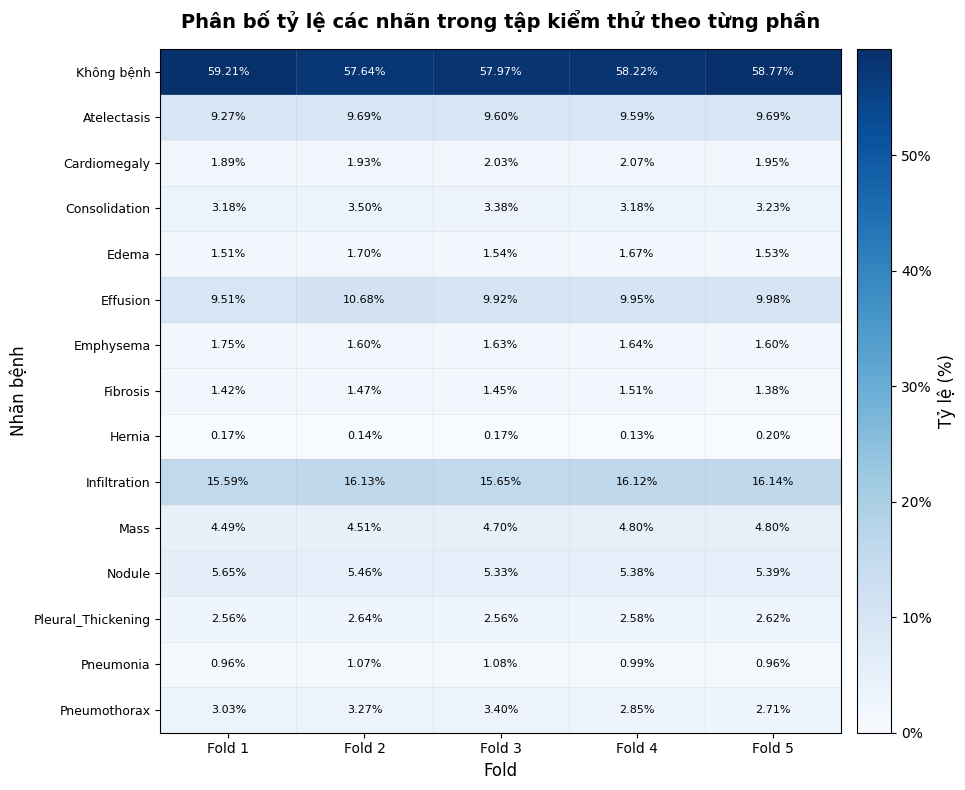

In [20]:
# Thống kê số liệu
validation_distribution_rows = []

for fold in range(1, NUMBER_OF_FOLDS + 1):

    fold_val = train_df[train_df["Fold"] == fold]
    val_total = len(fold_val)

    # 14 nhãn bệnh
    for label in CLASSES:

        val_positive = int(fold_val[label].sum())

        validation_distribution_rows.append({
            "Lớp": label,
            "Fold": fold,
            "Số ảnh dương tính": val_positive,
            "Tổng số ảnh": val_total,
            "Tỷ lệ": (val_positive / val_total if val_total > 0 else 0.0),
        })

    # No Finding
    val_no_finding = int((fold_val[CLASSES].sum(axis=1) == 0).sum())

    validation_distribution_rows.append({
        "Lớp": NO_FINDING_LABEL,
        "Fold": fold,
        "Số ảnh dương tính": val_no_finding,
        "Tổng số ảnh": val_total,
        "Tỷ lệ": (val_no_finding / val_total if val_total > 0 else 0.0),
    })


validation_distribution_df = pd.DataFrame(validation_distribution_rows)

label_order = [NO_FINDING_LABEL] + sorted(CLASSES)

validation_distribution_df["Lớp"] = pd.Categorical(
    validation_distribution_df["Lớp"],
    categories=label_order,
    ordered=True
)

validation_distribution_df = (
    validation_distribution_df
    .sort_values(["Lớp", "Fold"])
    .reset_index(drop=True)
)


validation_distribution_pivot = validation_distribution_df.pivot(
    index="Lớp",
    columns="Fold",
    values="Tỷ lệ",
)

validation_distribution_pivot = (
    validation_distribution_pivot.reindex(label_order)
)

validation_distribution_pivot.columns = [
    f"Fold {fold}"
    for fold in validation_distribution_pivot.columns
]


# Bảng thống kê
validation_distribution_table = (validation_distribution_pivot.reset_index().copy())

validation_distribution_table["Lớp"] = (
    validation_distribution_table["Lớp"]
    .astype(str)
    .replace({"No Finding": "Không bệnh"})
)

display(
    validation_distribution_table
    .style
    .hide(axis="index")
    .format({
        f"Fold {fold}": "{:.2%}"
        for fold in range(1, NUMBER_OF_FOLDS + 1)
    })
    .set_caption("Phân bố tỷ lệ các nhãn trong tập kiểm thử theo từng phần")
    .set_properties(**{
        "text-align": "center",
        "padding": "7px 12px",
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("margin-bottom", "10px"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("vertical-align", "middle"),
                ("font-weight", "bold"),
                ("padding", "7px 12px"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("vertical-align", "middle"),
            ],
        },
    ])
)


# Biểu đồ nhiệt
validation_data = validation_distribution_pivot.to_numpy(dtype=float)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(
    validation_data,
    aspect="auto",
    cmap="Blues",
    vmin=0,
    vmax=validation_data.max()
)

ax.set_xticks(np.arange(len(validation_distribution_pivot.columns)))
ax.set_xticklabels(validation_distribution_pivot.columns, fontsize=10)

validation_display_labels = [
    "Không bệnh" if str(label) == "No Finding" else str(label)
    for label in validation_distribution_pivot.index
]

ax.set_yticks(np.arange(len(validation_distribution_pivot.index)))
ax.set_yticklabels(validation_display_labels, fontsize=9)
threshold = validation_data.max() * 0.55

for row in range(validation_data.shape[0]):
    for col in range(validation_data.shape[1]):
        value = validation_data[row, col]
        ax.text(
            col,
            row,
            f"{value * 100:.2f}%",
            ha="center",
            va="center",
            fontsize=8,
            color="white" if value >= threshold else "black"
        )

ax.set_title(
    "Phân bố tỷ lệ các nhãn trong tập kiểm thử theo từng phần",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Fold", fontsize=12)
ax.set_ylabel("Nhãn bệnh", fontsize=12)
cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Tỷ lệ (%)", fontsize=12)

cbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.set_xticks(np.arange(-0.5, validation_data.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, validation_data.shape[0], 1), minor=True)
ax.grid(which="minor", linewidth=0.5, alpha=0.25)
ax.tick_params(which="minor", bottom=False, left=False)

plt.tight_layout()
plt.show()

## 5. Ghép ảnh với đường dẫn thực tế

In [21]:
def attach_image_path(df):
    df = df.copy()
    df["original_path"] = df[ID_COLUMN].map(
        lambda image_name: str(image_map[image_name]) if image_name in image_map else None
    )
    return df

train_df = attach_image_path(train_df)
test_df = attach_image_path(test_df)

for name, df in {
    "Tập dữ liệu huấn luyện": train_df,
    "Tập dữ liệu kiểm tra": test_df,
}.items():
    missing = int(df["original_path"].isna().sum())
    
    print_message(name, f"{'Ảnh không tìm thấy':<{MIN_MESSAGE_WIDTH}}: {missing:<{MIN_NUMBER_WIDTH},} ảnh")
    assert missing == 0, f"{name} không tìm thấy trên ổ đĩa."

Tập dữ liệu huấn luyện        : Ảnh không tìm thấy  : 0        ảnh
Tập dữ liệu kiểm tra          : Ảnh không tìm thấy  : 0        ảnh


## 4. Chuyển đổi kích cỡ ảnh
#### Từ 1028 x 1028 --> RESIZE đề ra

## 4.1. Hàm xử lý chuyển đổi kích cỡ ảnh

In [22]:
if RESIZED_DIRECTORY.exists():
    shutil.rmtree(RESIZED_DIRECTORY)

RESIZED_DIRECTORY.mkdir(parents=True, exist_ok=True)
all_df = pd.concat([train_df, test_df],ignore_index=True)

unique_images = (all_df[[ID_COLUMN, "original_path"]].drop_duplicates(subset=[ID_COLUMN]).reset_index(drop=True))
resized_paths = {}

for _, row in TqdmComma(
    unique_images.iterrows(),
    total=len(unique_images),
    desc="Điều chỉnh kích cỡ ảnh"
):

    image_name = row[ID_COLUMN]
    source_path = Path(row["original_path"])
    target_path = RESIZED_DIRECTORY / image_name

    # Không xử lý lại nếu ảnh đã tồn tại
    if not target_path.exists():

        with Image.open(source_path) as image:
            image = image.convert("L")
            image = image.resize((IMAGE_SIZE, IMAGE_SIZE), Image.Resampling.LANCZOS)
            image.save(target_path, format="PNG")

    resized_paths[image_name] = str(target_path.resolve())

for df in [train_df, test_df]:

    df["image_path"] = (df[ID_COLUMN].map(resized_paths))

Điều chỉnh kích cỡ ảnh: 100%|██████████| 112,120/112,120 [36:39<00:00, 50.99it/s]


## 5. Thống kê dữ liệu

In [23]:
# Dữ liệu tổng có cột fold
train_df.to_csv(TRAIN_FOLDS_DIRECTORY, index=False)

# Official test được giữ nguyên, không có fold
if "Fold" in test_df.columns:
    test_df = test_df.drop(columns=["Fold"])
test_df.to_csv(TEST_DIRECTORY, index=False)


# Thông tin classes + preprocessing
with open(DATASET_INFO_DIRECTORY, "w", encoding="utf-8") as file:
    json.dump(
        {
            "dataset_name": to_snake_case(DATASET_NAME),
            "seed": SEED,
            "cuDNN_deterministic" : CUDNN_DETERMINISTIC, 
            "cuDNN_benchmark" : CUDNN_BENCHMARK,
            "deterministic_algorithms" : DETERMINISTIC_ALGORITHMS,
            "image_size": IMAGE_SIZE if RESIZE_IMAGES else None,
            
            "classes": CLASSES,
            "no_finding": NO_FINDING_LABEL,
            "no_finding_is_class": False,
            "label_separator": LABEL_SEPARATOR,
            "number_of_folds": NUMBER_OF_FOLDS,
            "split_strategy": "patient-level multilabel stratified k-fold",
            "official_test_preserved": True,
        },
        file,
        indent=4,
        ensure_ascii=False,
    )

print_heading("Đã tiền xử lý dữ liệu thành công")

Đã tiền xử lý dữ liệu thành công
